# profile_decodification

Decode the LDA top-10 day-type profiles into VQ-VAE behavioral features and plot the
feature distribution per pattern.


In [9]:
import os
import pickle
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TOP10_CSV = PROJECT_ROOT / "results/lda/tables/lda_topics_top10.csv"

# Decoded VQ-VAE embedding vectors (profile id -> behavioral feature vector)
DECODED_PKL = PROJECT_ROOT / "data/output_vq_vae/decoded_embedding_vectors_a0.pkl"

OUTPUT_FIG = (
    PROJECT_ROOT / "results/lda/figures/decoded_topic_plots/decoded_top10_lda_patterns.png"
)

# Order of features in each decoded vector
FEATURE_NAMES = [
    "sleep_start",
    "location_distance",
    "location_time_home",
    "sleep_duration",
    "activity_walking",
    "app_usage_total",
    "location_clusters_count",
    "steps_steps_total",
    "weekend",
    "practiced_sport",
]

print("Top-10 CSV :", TOP10_CSV)
print("Decoded PKL:", DECODED_PKL)

Top-10 CSV : /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/results/lda/tables/lda_topics_top10.csv
Decoded PKL: /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/data/output_vq_vae/decoded_embedding_vectors_a0.pkl


## 1 · Top-10 profiles → decoded features

In [10]:
terms_topic = pd.read_csv(TOP10_CSV)

with open(DECODED_PKL, "rb") as f:
    embedding_counts = pickle.load(f)

# Map each profile id to its decoded vector and expand into named feature columns
df_final = terms_topic.copy()
df_final["embedding_vector"] = df_final["profile"].map(embedding_counts)
df_final = df_final.dropna(subset=["embedding_vector"]).reset_index(drop=True)

features = pd.DataFrame(df_final["embedding_vector"].tolist(), columns=FEATURE_NAMES)
df_final = pd.concat([df_final.drop(columns=["embedding_vector"]), features], axis=1)
df_final = df_final.drop(columns=["weekend"])

feature_cols = [c for c in FEATURE_NAMES if c != "weekend"]
df_final.head()

,topic,profile,sleep_start,location_distance,location_time_home,sleep_duration,activity_walking,app_usage_total,location_clusters_count,steps_steps_total,practiced_sport
0,0,126,-6299.330078,6259.673828,760.604126,31635.656250,3076.603027,10433.802734,2.371345,6701.609375,0.0
1,0,80,-6002.826660,6455.256836,757.518860,31309.898438,3051.670654,10428.599609,2.343111,6655.813477,0.0
2,0,164,-6313.871094,5349.956543,765.607239,31637.613281,2996.453613,10473.359375,2.351614,6225.498047,0.0
3,0,162,-6170.797852,6696.689453,751.293274,33019.847656,3206.520508,11001.301758,2.372304,7120.869141,0.0
4,0,127,-6339.684082,5907.305176,754.655273,31940.416016,3040.358643,10509.728516,2.351895,6636.954102,0.0


## 2 · Feature distribution by day type per pattern

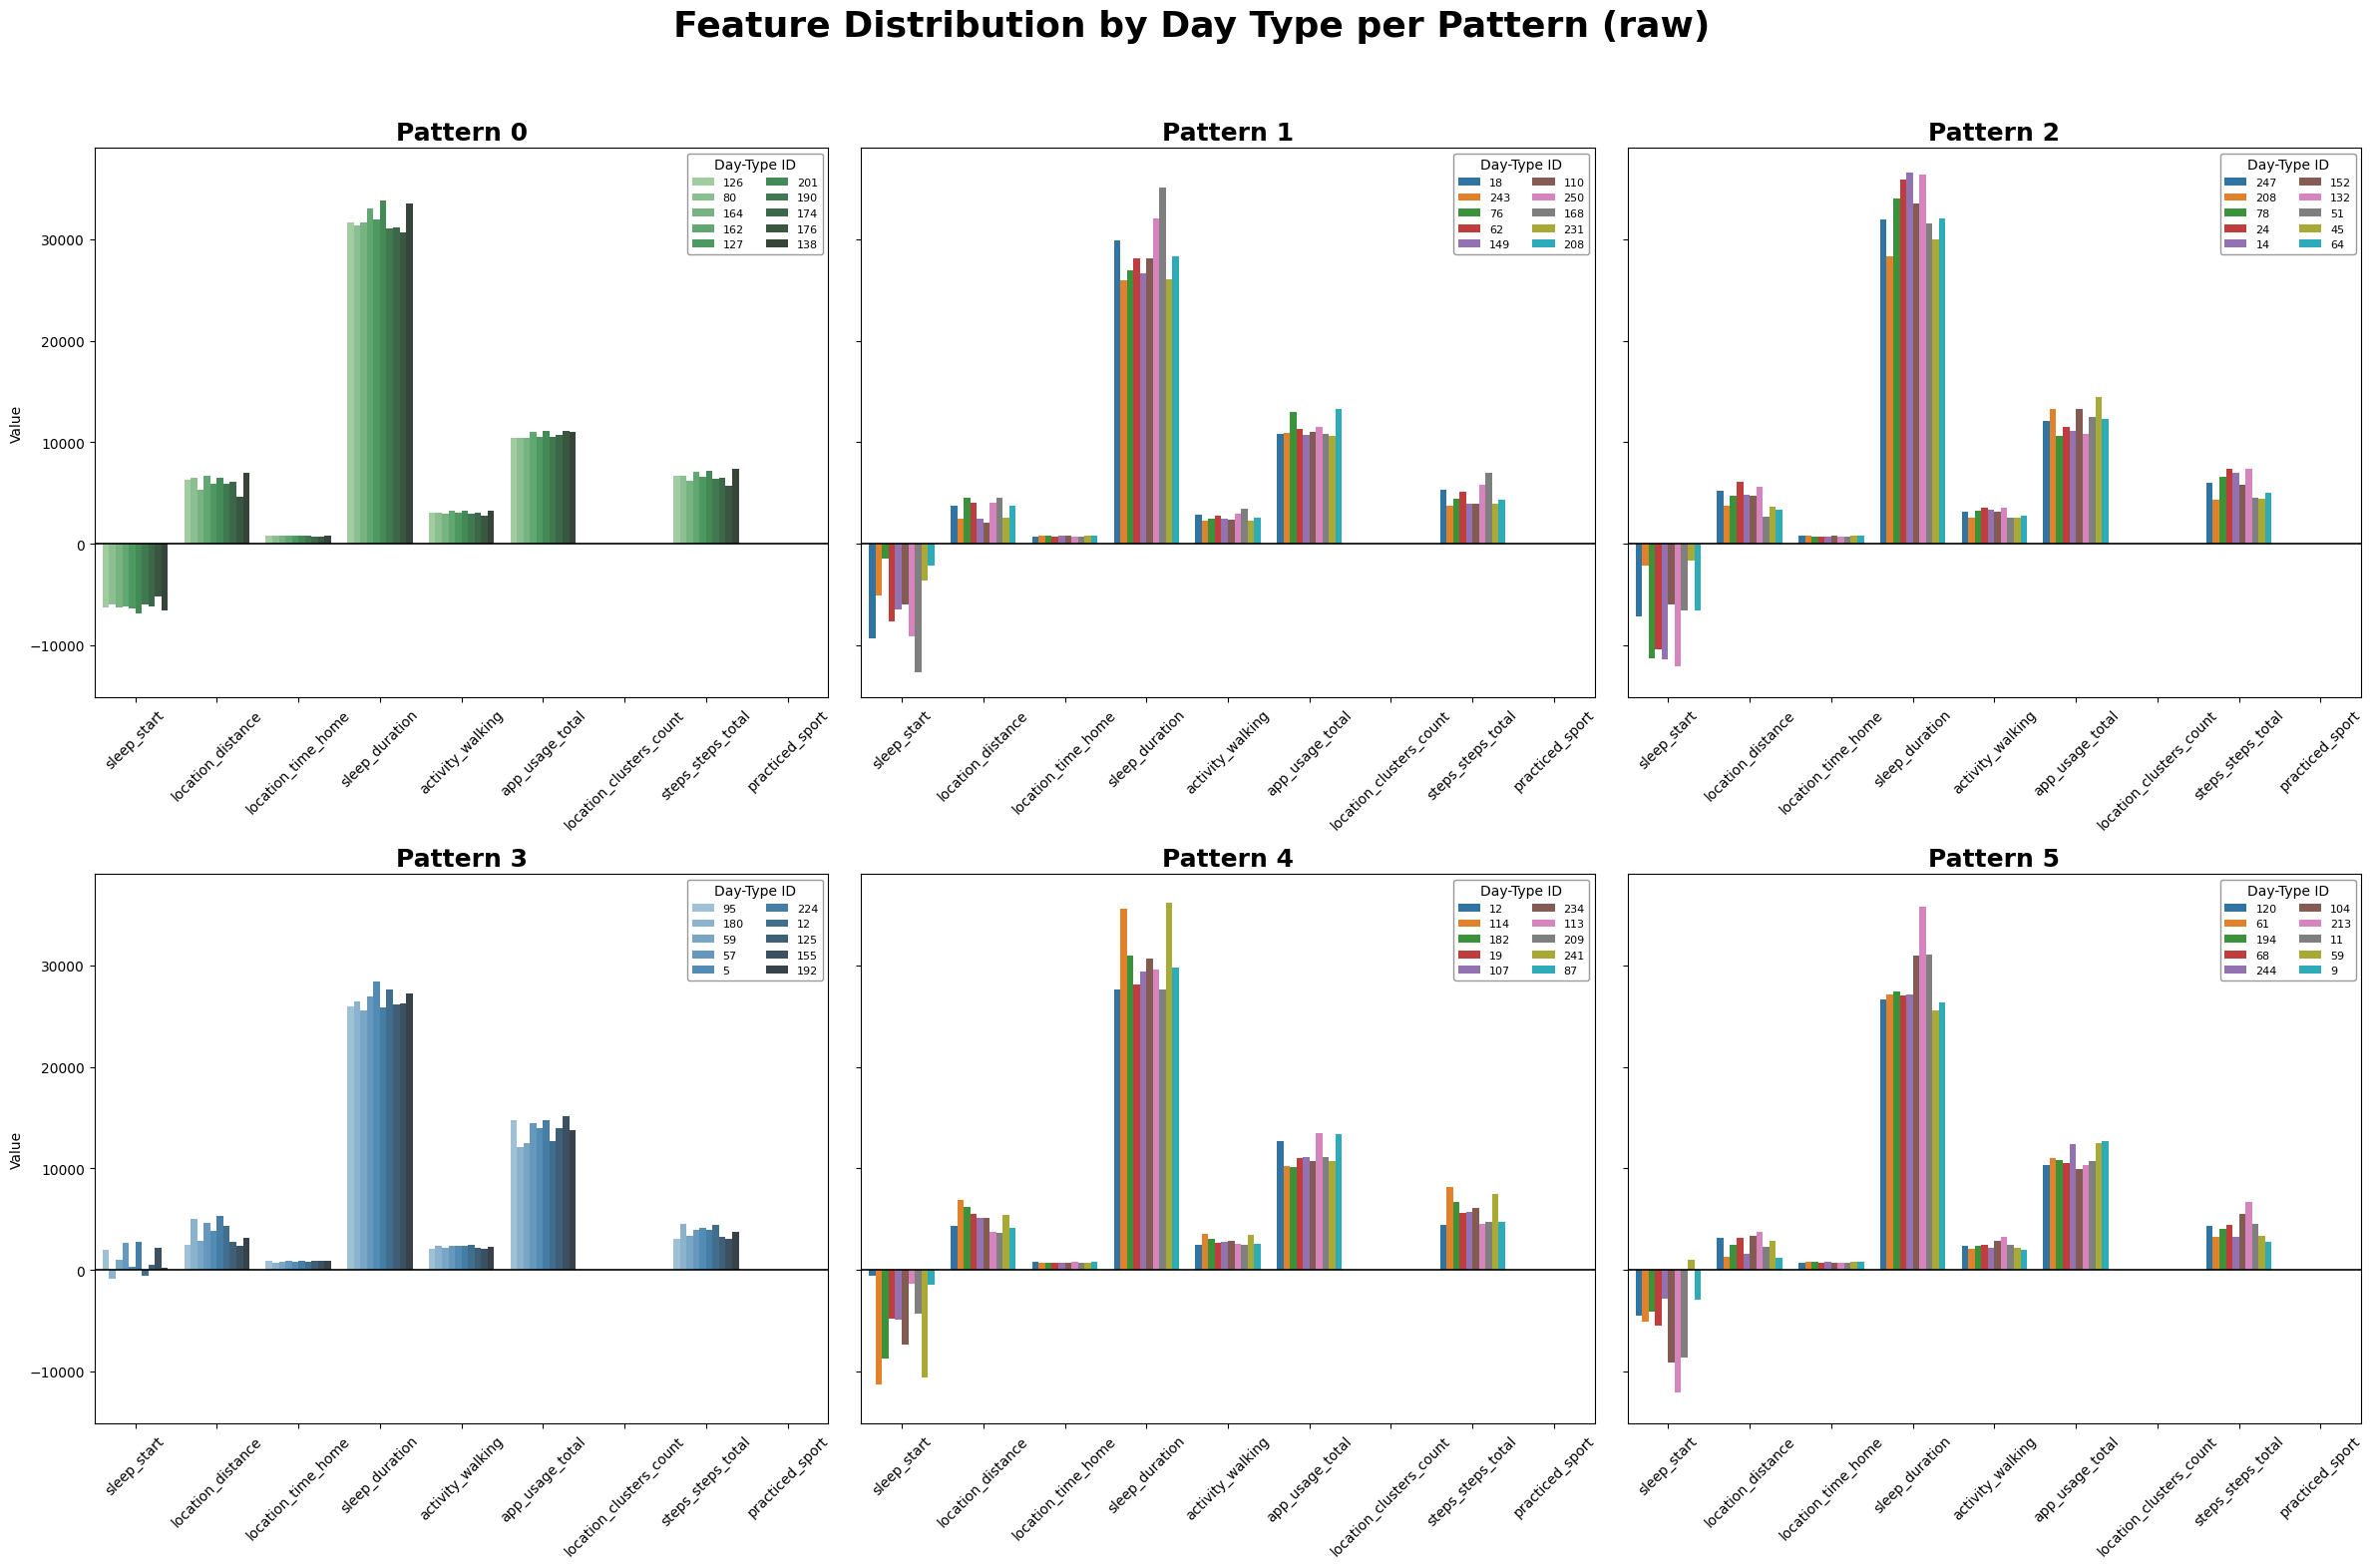

In [11]:
palette_map = {0: "Greens_d", 3: "Blues_d"}
default_palette = "tab10"

topics = sorted(df_final["topic"].unique())
n_topics = len(topics)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 16), sharey=True)
axes = axes.flatten()

for i, topic_id in enumerate(topics):
    ax = axes[i]
    df_topic = df_final[df_final["topic"] == topic_id].copy()
    df_topic["profile"] = df_topic["profile"].astype(str)

    df_melted = df_topic.melt(
        id_vars=["profile"], value_vars=feature_cols,
        var_name="Feature", value_name="Value",
    )

    current_palette = palette_map.get(topic_id, default_palette)
    sns.barplot(data=df_melted, x="Feature", y="Value", hue="profile",
                palette=current_palette, ax=ax)

    ax.set_title(f"Pattern {topic_id}", fontsize=18, fontweight="bold")
    ax.set_ylabel("Value" if i % n_cols == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.axhline(0, color="black", linewidth=1.2)
    ax.legend(title="Day-Type ID", loc="upper right", fontsize="8",
              ncol=2, frameon=True, edgecolor="gray")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distribution by Day Type per Pattern (raw)", fontsize=26, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()  # intermediate figure (not saved)

## 3 · Normalize features (z-score)

In [12]:
from sklearn.preprocessing import StandardScaler

feature_columns = [c for c in df_final.columns if c not in ["topic", "profile"]]

df_final_scal = df_final.copy()
scaler = StandardScaler()
df_final_scal[feature_columns] = scaler.fit_transform(df_final_scal[feature_columns])

df_final_scal.head()

,topic,profile,sleep_start,location_distance,location_time_home,sleep_duration,activity_walking,app_usage_total,location_clusters_count,steps_steps_total,practiced_sport
0,0,126,-0.322952,1.399459,-0.018849,0.541415,0.845010,-0.965096,0.370200,1.093270,-0.185695
1,0,80,-0.249284,1.532097,-0.070951,0.439860,0.786924,-0.968815,0.307877,1.060531,-0.185695
2,0,164,-0.326565,0.782520,0.065642,0.542025,0.658281,-0.936818,0.326646,0.752897,-0.185695
3,0,162,-0.291018,1.695829,-0.176086,0.972937,1.147686,-0.559411,0.372317,1.393000,-0.185695
4,0,127,-0.332979,1.160495,-0.119310,0.636424,0.760569,-0.910819,0.327266,1.047048,-0.185695


## 4 · Final figure: feature distribution by day type per pattern (normalized)

Saved: /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/results/lda/figures/decoded_topic_plots/decoded_top10_lda_patterns.png


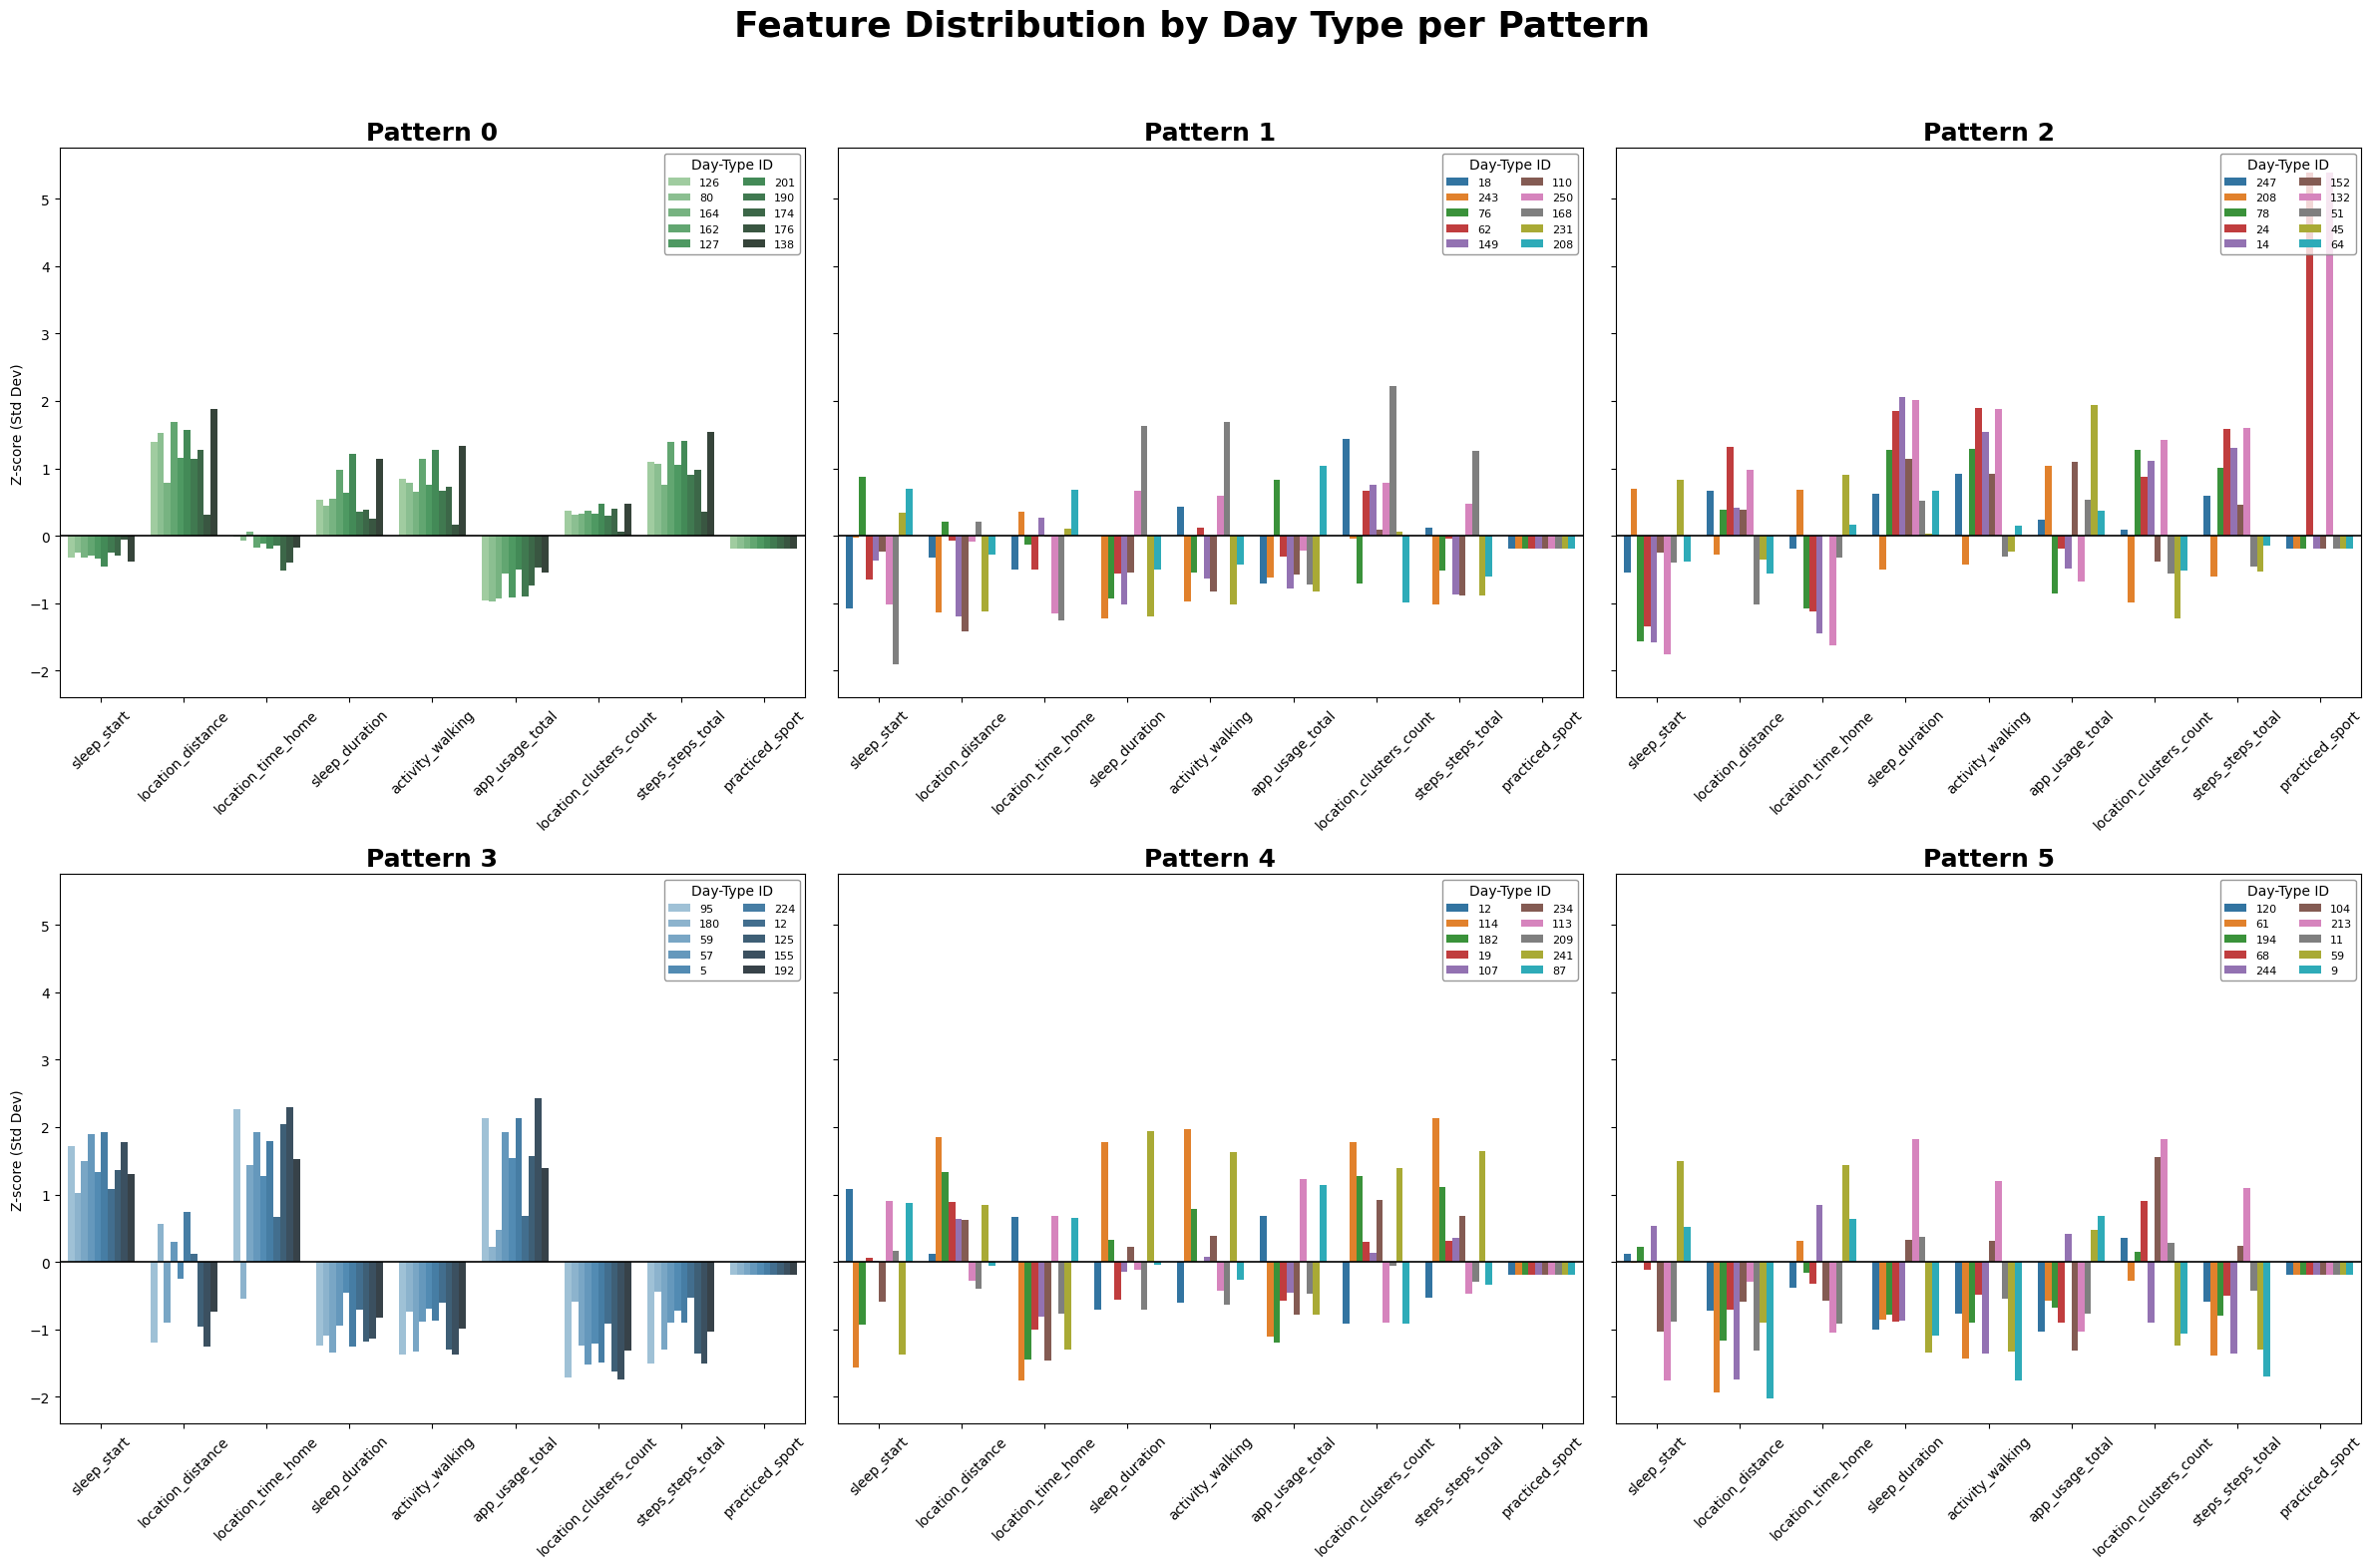

In [13]:
topics = sorted(df_final_scal["topic"].unique())
n_topics = len(topics)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 16), sharey=True)
axes = axes.flatten()

for i, topic_id in enumerate(topics):
    ax = axes[i]
    df_topic = df_final_scal[df_final_scal["topic"] == topic_id].copy()
    df_topic["profile"] = df_topic["profile"].astype(str)

    df_melted = df_topic.melt(
        id_vars=["profile"], value_vars=feature_cols,
        var_name="Feature", value_name="Value",
    )

    current_palette = palette_map.get(topic_id, default_palette)
    sns.barplot(data=df_melted, x="Feature", y="Value", hue="profile",
                palette=current_palette, ax=ax)

    ax.set_title(f"Pattern {topic_id}", fontsize=18, fontweight="bold")
    ax.set_ylabel("Z-score (Std Dev)" if i % n_cols == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.axhline(0, color="black", linewidth=1.2)
    ax.legend(title="Day-Type ID", loc="upper right", fontsize="8",
              ncol=2, frameon=True, edgecolor="gray")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distribution by Day Type per Pattern", fontsize=26, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])

OUTPUT_FIG.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_FIG, dpi=300, bbox_inches="tight")
print(f"Saved: {OUTPUT_FIG}")
plt.show()